In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import scipy.stats as st
#import theano.tensor as tt
import matplotlib.pyplot as plt
from ann_functions import import_data
from keras.models import load_model
from keras.initializers import glorot_uniform
import keras.backend as K
from keras.utils import custom_object_scope

np.random.seed(42)


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


(array([46., 20., 21.,  8.,  7., 16.,  9., 14., 17., 42.]),
 array([7.52384932e-05, 1.00025293e-01, 1.99975348e-01, 2.99925402e-01,
        3.99875457e-01, 4.99825511e-01, 5.99775566e-01, 6.99725621e-01,
        7.99675675e-01, 8.99625730e-01, 9.99575784e-01]),
 <BarContainer object of 10 artists>)

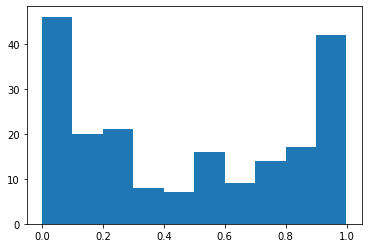

In [133]:
r=st.arcsine.rvs(scale=1,size=200)
plt.hist(r)


In [28]:
def NN_MF(q,K1,K2,K3):
    out1=K1.predict(q)
 #   print(out1.shape)
 #   print(q.shape)
    in2 = np.hstack((q, out1))
    out2=K2.predict(in2)
    in3 = np.hstack((in2, out2))
    approx_model_output=K3.predict(in3)
    return approx_model_output
 
def logit(p):
    return np.log(p / (1 - p))

def inv_logit(z):
    return 1 / (1 + np.exp(-z))

def scaled_logit_normal_prior(num_samples, scale_factor=0.2, mean=0, std_dev=1):
    # Genera campioni dalla distribuzione normale standard
    z_samples = np.random.normal(mean, std_dev, num_samples)

    # Applica la trasformazione logit inversa
    p_samples = inv_logit(z_samples)

    # Ridimensiona i campioni nell'intervallo (0, 0.2)
    scaled_samples = p_samples * scale_factor

    return scaled_samples  

def Metropolis_Hastings(q0, N, sigma, U_test, K1,K2,K3): # implementation of the Random Walk Metropolis-Hastings algorithm
    # q0= initial value 
    # N = length Markov chain
    # sigma = std deviation
    # U_test = test set
    # K1 = first NN
    # K2 = second NN
    # K3 = third NN
    rng = np.random.default_rng(2022)

    dimension= q0.shape[0]
    q = np.ones([N+1, dimension])
    q[0, :] = q0.T
    #print(q[0,:])
    accepted = 0
    rejected = 0
    U_NN_old=NN_MF(q0,K1,K2,K3)
    #print(U_NN_old)
    for i in range(N):
        #q_star = np.random.multivariate_normal(mean=q[i, :], cov=sigma*np.eye(dimension))
        #q_star=np.random.uniform(0., 0.4, size=(1, dimension))
        #q_star=st.arcsine.rvs(scale=1,size=dimension)
        q_star=scaled_logit_normal_prior(1,0.2,q[i,:],sigma)
        U_NN=NN_MF(q_star.reshape(dimension,1),K1,K2,K3)
       # print(U_NN)
        #value_old=np.exp(((U_NN-U_test)@(U_NN-U_test)/(2*sigma)))
        #a = np.exp(((U_NN.reshape(U_test.shape[0])-U_test.reshape(U_test.shape[0]))@(U_NN.reshape(U_test.shape[0])-U_test.reshape(U_test.shape[0]))/(2*sigma)))/np.maximum(np.exp(((U_NN_old.reshape(U_test.shape[0])-U_test.reshape(U_test.shape[0])/(2*sigma**sigma))@(U_NN_old.reshape(U_test.shape[0])-U_test.reshape(U_test.shape[0]))/(2*sigma**sigma))), np.finfo(np.float64).eps)
        a = np.exp(((U_NN.reshape(1)-U_test.reshape(1))@(U_NN.reshape(1)-U_test.reshape(1))/(2*sigma)))/np.maximum(np.exp(((U_NN_old.reshape(1)-U_test.reshape(1)/(2*sigma**sigma))@(U_NN_old.reshape(1)-U_test.reshape(1))/(2*sigma**sigma))), np.finfo(np.float64).eps)

       # print("--")
       # print(a)
        u = np.random.uniform()
        if (u<a):
            q[i+1, :] = q_star
            accepted = accepted+1
            U_NN_old=U_NN
        else:
            q[i+1, :] = q[i, :]
            rejected = rejected+1
    ratio = accepted/(accepted+rejected)
    return q, ratio, U_NN

def autocovariance(X): # Autocovariance of a Markov chain X, X tail of q after burn-in lag B
    mu = np.mean(X, axis=0)
    N = len(X[:, 0])
    cov = np.zeros([N-1, X.shape[1]])
    
    for k in range(N-1):
        for i in range(N-k-1):
            cov[k, :] += ((X[i+k, :])-mu)*(X[i, :]-mu)
        cov[k, :] = (1/(N-k-1))*cov[k, :]
        
    return cov

def autocorrelation(autocov): # Autocorrelation of a Markov chain, calculated from its autocovariance
    corr = np.zeros(np.shape(autocov))
    for i in range(int(len(autocov[0, :, 0]))):
        for j in range(autocov.shape[2]):
            corr[:, i, j] = np.divide(autocov[:, i, j], np.maximum(np.abs(autocov[:, 0, j]), np.finfo(np.float64).eps))
            #corr[:, i, 1] = np.divide(autocov[:, i, 1], np.maximum(np.abs(autocov[:, 0, 1]), np.finfo(np.float64).eps))
    
    return corr

def get_M(autocov): # Last element of the chain used to calculate sigma^2_mcmc
    M1 = None
    for k in range(int(len(autocov[:, 0])/2)):
        if ((autocov[2*k, 0] + autocov[2*k+1, 0])<=0):
            M1 = 2*k
            break
    if M1 is None:
        M1 = int(len(autocov[:, 0])-2)
    M2 = None
    for j in range(int(len(autocov[:, 1])/2)):
        if ((autocov[2*j, 1] + autocov[2*j+1, 1])<=0) :
            M2 = 2*j
            break
    if M2 is None:
        M2 = int(len(autocov[:, 1])-2)
    
    return M1, M2

def get_sigma(autocov): # Time-average variance constant of a Markov chain, calculated from its autocovariance
    # Calculate the
    [M1, M2] = get_M(autocov)
    id1 = range(1, M1)
    S1 = autocov[0, 0] + 2*np.sum(autocov[id1, 0])
    id2 = range(1, M2)
    S2 = autocov[0, 1] + 2*np.sum(autocov[id2, 1])

    return [S1, S2]


def effective_sample_size(autocov): # effective sample size of a Markov chain, calculated from its autocovariance
    [n, N] = np.shape(autocov[:, :, 0])
    ess = np.zeros([n, autocov.shape[2]])
    for i in range(n):
        sigma = get_sigma(autocov[i, :, :])
        for j in range(autocov.shape[2]):
            ess[i, j] = N*np.divide(autocov[i, 0, j], np.maximum(sigma[j],  np.finfo(np.float64).eps))
        #ess[i, 1] = N*np.divide(autocov[i, 0, 1], np.maximum(sigma[1],  np.finfo(np.float64).eps))

    return ess

In [21]:
# cell 1                                                        
#file_path_HF = "../DATA/reaction_diffusion_HF.mat"
#(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
mask= np.where(reaction_HF_test<0.7)[0]
#U_HF_test = U_HF_test[:, -1, 44,44]
n_HF = 1

# ADD NOISE
#noise_stddev = np.mean(U_HF_test)       # value?
#noise = np.random.normal(0, noise_stddev, len(U_HF_test))
#U_HF_test_selection = U_HF_test + noise
U_HF_test_selection=U_HF_test[mask]
#reaction_HF_test=reaction_HF_test[mask][0:n_HF]
reaction_HF_test=reaction_HF_test[mask][9,0]
reaction_HF_test=reaction_HF_test-0.5



permutation = np.random.permutation(len(U_HF_test_selection))
#U_HF_test_selection = U_HF_test_selection[permutation][0:n_HF]
U_HF_test_selection = U_HF_test_selection[9]



# Definisci la tua funzione di attivazione personalizzata (in codice finale, dove tutto andrà da inizio a fine, non credo questa parte sarà più necessaria...)
def custom_activation(x):
    # Implementa la tua logica personalizzata qui
    return x + K.square(K.sin(x))

# Aggiungi la tua funzione di attivazione personalizzata al dizionario custom_objects
custom_objects = {'custom_activation': custom_activation, 'glorot_uniform': glorot_uniform()}

# Carica il modello utilizzando custom_objects
with custom_object_scope(custom_objects):
    keras_model1 = load_model("modelLF.h5")
    keras_model2 = load_model("modelLin.h5")
    keras_model3 = load_model("finalModel.h5")



In [24]:
print(U_HF_test_selection)
print(reaction_HF_test)

0.4559818649874315
0.18367346938775508


In [29]:
#mu_0=np.random.uniform(0.5,1.5,size=(U_HF_test_selection.shape[0],1))
mu_0=np.random.uniform(0.,0.2,size=(1,1))

sigma=0.1
N=150
n=10

final_q = np.zeros([n, 1])
final_q_ham = np.zeros([n, 1])
ratio = np.zeros(n)
big_q = np.zeros([n,N+1, 1])
big_q_ham = np.zeros([n,N+1, 1])

for i in range(n):
        q, ratio,U = Metropolis_Hastings(mu_0, N, sigma,U_HF_test_selection,keras_model1,keras_model2,keras_model3)
        print(ratio)
        final_q[i, :] = q[-1, :]
        big_q[i, :, :] = q
        if (i+1)%(int(np.floor(n/10))) == 0:
            print("Iteration: ", i+1, "/", n)

exp_q = np.mean(big_q, axis=0)
var_q = np.var(big_q, axis=0)


## Calculate autocorrelation of both chains q(:, 0) and q(:, 1)
B = 20
idx = B+np.asarray(range(N-B))

tail_qx = big_q[:, idx, 0]
#tail_qy = big_q[:, idx, 1]
tail_q = big_q[:, idx, :]
tail_qx_ham = big_q_ham[:, idx, 0]
#tail_qy_ham = big_q_ham[:, idx, 1]

print("Calculating covariance...")
cov = np.zeros([n, len(idx)-1, tail_q.shape[2]])
for i in range(n):
    cov[i, :, :] = autocovariance(tail_q[i, :, :])
print("Calculating correlation...")
corr = np.mean(autocorrelation(cov), axis=0)


## Calculate effective sample size
#print("Calculating ESS...")
#ESS = effective_sample_size(cov)
#ESS = np.sort(ESS, axis=0)
#id_min_ESS = int(np.floor(n/40))
#id_ESS = id_min_ESS+np.asarray(range(n-2*id_min_ESS))
#ESS_reduced = ESS[id_ESS, :]


avx = np.reshape(tail_qx, -1)
#avy = np.reshape(tail_qy, -1)
avx_ham = np.reshape(tail_qx_ham, -1)
#avy_ham = np.reshape(tail_qy_ham, -1)

# ancora regolato su caso bidimensionale
fig, axs2 = plt.subplots(2, 4)
axs2[0, 0].plot(exp_q[:, 0])
axs2[0, 0].set_title('mean 1')
#axs2[1, 0].plot(exp_q[:, 1])
#axs2[1, 0].set_title('mean 2')

axs2[0, 1].plot(var_q[:, 0])
axs2[0, 1].set_title('variance 1')

#axs2[1, 1].plot(var_q[:, 1])
#axs2[1, 1].set_title('variance 2')
axs2[0, 2].plot(cov[-1, :, 0])
axs2[0, 2].set_title('covariance 1')
#axs2[1, 2].plot(cov[-1, :, 1])
#axs2[1, 2].set_title('covariance 2')

axs2[0, 3].plot(corr[:, 0])
axs2[0, 3].set_title('autocorrelation 1')

#axs2[1, 3].plot(corr[:, 1])
#axs2[1, 3].set_title('autocorrelation 2')


# EFFECTIVE SAMPLE SIZE DA RIPARARE
#fig, ax3 = plt.subplots(1, 2)
#ax3[0].hist(ESS_reduced[:, 0], 25, density=False)
#ax3[0].set_title('ESS 1')

#ax3[1].hist(ESS_reduced[:, 1], 25, density=False)
#ax3[1].set_title('ESS 2')




plt.show()                        


            

1/1 [==============================] - 0s 43ms/step


1/1 [==============================] - 0s 8ms/step
1.0
Iteration:  1 / 10
1/1 [==============================] - 0s 23ms/step
1.0
Iteration:  2 / 10
1/1 [==============================] - 0s 45ms/step
1.0
Iteration:  3 / 10
1/1 [==============================] - 0s 25ms/step
1.0
Iteration:  4 / 10
1/1 [==============================] - 0s 17ms/step
1.0
Iteration:  5 / 10
1/1 [==============================] - 0s 25ms/step
1.0
Iteration:  6 / 10
1/1 [==============================] - 0s 25ms/step
1.0
Iteration:  7 / 10
1/1 [==============================] - 0s 25ms/step
1.0
Iteration:  8 / 10
1/1 [==============================] - 0s 25ms/step
1.0
Iteration:  9 / 10
1/1 [==============================] - 0s 24ms/step
1.0
Iteration:  10 / 10


IndexError: index 1 is out of bounds for axis 2 with size 1

Calculating covariance...
Calculating correlation...


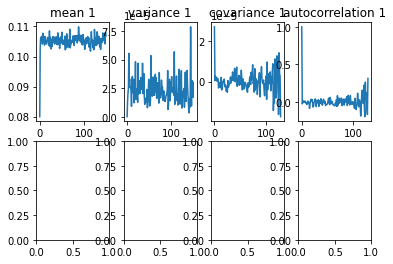

In [31]:
## Calculate autocorrelation of both chains q(:, 0) and q(:, 1)
B = 20
idx = B+np.asarray(range(N-B))

tail_qx = big_q[:, idx, 0]
#tail_qy = big_q[:, idx, 1]
tail_q = big_q[:, idx, :]
tail_qx_ham = big_q_ham[:, idx, 0]
#tail_qy_ham = big_q_ham[:, idx, 1]

print("Calculating covariance...")
cov = np.zeros([n, len(idx)-1, tail_q.shape[2]])
for i in range(n):
    cov[i, :, :] = autocovariance(tail_q[i, :, :])
print("Calculating correlation...")
corr = np.mean(autocorrelation(cov), axis=0)


## Calculate effective sample size
#print("Calculating ESS...")
#ESS = effective_sample_size(cov)
#ESS = np.sort(ESS, axis=0)
#id_min_ESS = int(np.floor(n/40))
#id_ESS = id_min_ESS+np.asarray(range(n-2*id_min_ESS))
#ESS_reduced = ESS[id_ESS, :]


avx = np.reshape(tail_qx, -1)
#avy = np.reshape(tail_qy, -1)
avx_ham = np.reshape(tail_qx_ham, -1)
#avy_ham = np.reshape(tail_qy_ham, -1)

# ancora regolato su caso bidimensionale
fig, axs2 = plt.subplots(2, 4)
axs2[0, 0].plot(exp_q[:, 0])
axs2[0, 0].set_title('mean 1')
#axs2[1, 0].plot(exp_q[:, 1])
#axs2[1, 0].set_title('mean 2')

axs2[0, 1].plot(var_q[:, 0])
axs2[0, 1].set_title('variance 1')

#axs2[1, 1].plot(var_q[:, 1])
#axs2[1, 1].set_title('variance 2')
axs2[0, 2].plot(cov[-1, :, 0])
axs2[0, 2].set_title('covariance 1')
#axs2[1, 2].plot(cov[-1, :, 1])
#axs2[1, 2].set_title('covariance 2')

axs2[0, 3].plot(corr[:, 0])
axs2[0, 3].set_title('autocorrelation 1')

#axs2[1, 3].plot(corr[:, 1])
#axs2[1, 3].set_title('autocorrelation 2')


# EFFECTIVE SAMPLE SIZE DA RIPARARE
#fig, ax3 = plt.subplots(1, 2)
#ax3[0].hist(ESS_reduced[:, 0], 25, density=False)
#ax3[0].set_title('ESS 1')

#ax3[1].hist(ESS_reduced[:, 1], 25, density=False)
#ax3[1].set_title('ESS 2')




plt.show()                        


In [30]:
B = 50
idx = B+np.asarray(range(N-B))

tail_qx = big_q[:, idx, 0]
tail_qy = big_q[:, idx, 1]
tail_q = big_q[:, idx, :]
tail_qx_ham = big_q_ham[:, idx, 0]
tail_qy_ham = big_q_ham[:, idx, 1]




print("Calculating covariance...")
cov = np.zeros([n, len(idx)-1, tail_q.shape[2]])
for i in range(n):
    cov[i, :, :] = autocovariance(tail_q[i, :, :])
print("Calculating correlation...")
corr = np.mean(autocorrelation(cov), axis=0)


## Calculate effective sample size
#print("Calculating ESS...")
#ESS = effective_sample_size(cov)
#ESS = np.sort(ESS, axis=0)
#id_min_ESS = int(np.floor(n/40))
#id_ESS = id_min_ESS+np.asarray(range(n-2*id_min_ESS))
#ESS_reduced = ESS[id_ESS, :]


avx = np.reshape(tail_qx, -1)
avy = np.reshape(tail_qy, -1)
avx_ham = np.reshape(tail_qx_ham, -1)
avy_ham = np.reshape(tail_qy_ham, -1)

# ancora regolato su caso bidimensionale

for i in range(U_HF_test_selection.shape[0]):
    plt.figure()  # Crea una nuova figura per ogni iterazione del ciclo
    fig, axs2 = plt.subplots(2, 2)
    axs2[0, 0].plot(exp_q[:, i])
    axs2[0, 0].set_title(f"Mean Parameter {i+1}", fontsize=10)
    
    axs2[0, 1].plot(var_q[:, i])
    axs2[0, 1].set_title(f"Variance Parameter {i+1}", fontsize=10)
    
    axs2[1, 0].plot(cov[-1, :, i])
    axs2[1, 0].set_title(f"Covariance Parameter {i+1}", fontsize=10)
    
    axs2[1, 1].plot(corr[:, i])
    axs2[1, 1].set_title(f"Correlation Parameter {i+1}", fontsize=10)
    
    # per effective sample size rifare funzione originaria che tiene ancora conto solo di due parametri
    #plt.figure()
    #plt.hist(ESS_reduced[:, i], 25, density=False, label=f"ESS Parameter {i+1}")
    
    






plt.show() 

IndexError: index 1 is out of bounds for axis 2 with size 1

In [ ]:
var_tot=np.var(exp_q)
mean=np.mean(var_q)

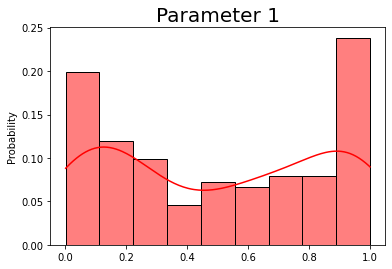

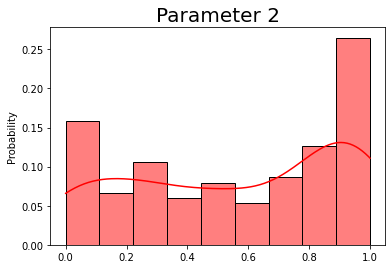

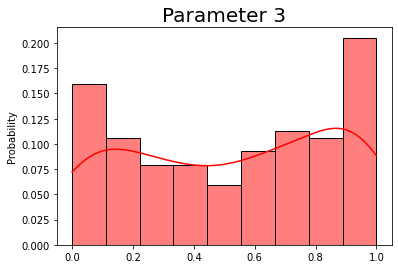

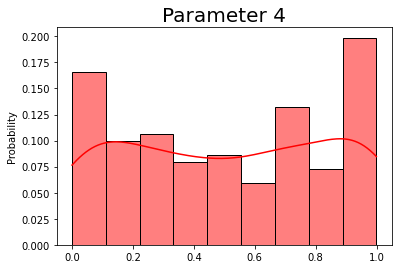

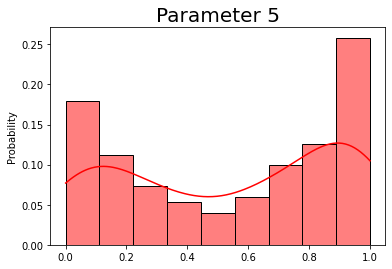

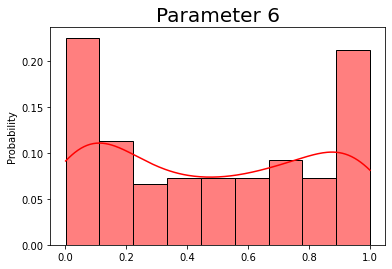

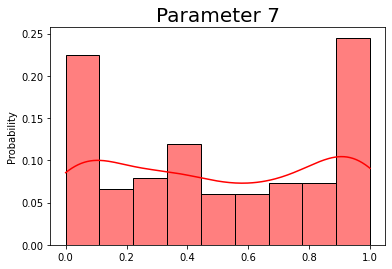

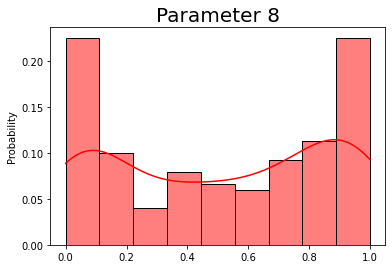

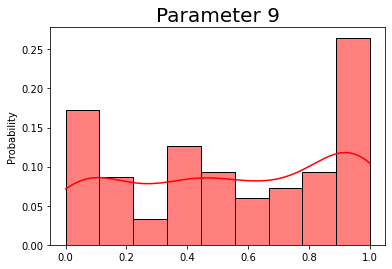

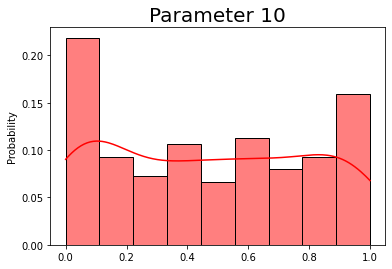

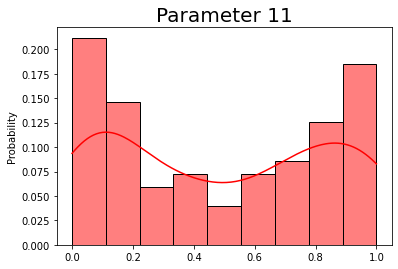

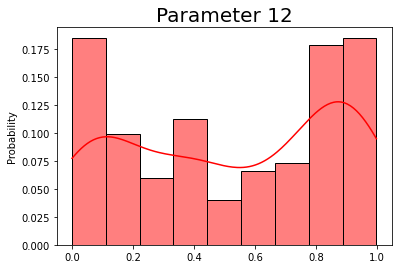

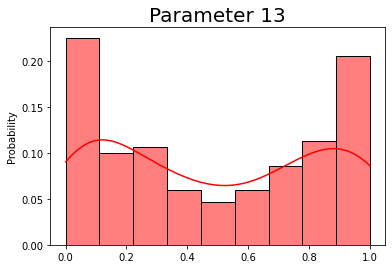

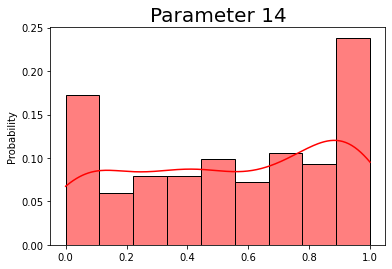

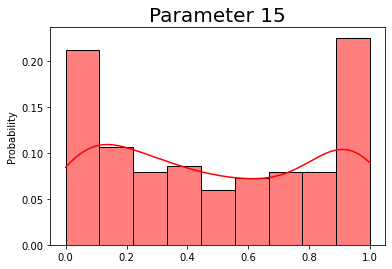

In [ ]:
for i in range(U_HF_test_selection.shape[0]):
    plt.figure()  # Crea una nuova figura per ogni iterazione del ciclo
    rel = sns.histplot(
        data=q[:, i],
        kde=True,
        stat="probability",
        color="r",
        label="probabilities",
    )
    plt.title(f"Parameter {i+1}", fontsize=20)
    plt.show()

In [142]:
print(q[-1,:].shape)

(15,)


In [143]:
print(U_HF_test)
print(U)

[ 0.27952176  0.83021857  0.95250871  0.5899364  -0.06765481 -0.68713166
 -0.96267251 -0.76552995 -0.20007425  0.45598186  0.89128288  0.90857869
  0.51032871 -0.11303117 -0.67910249 -0.94345778 -0.80289143 -0.32960855
  0.27127293  0.75497561  0.93725431  0.76070641  0.30556685 -0.25195164
 -0.7113785  -0.91989473 -0.81937476 -0.45628714  0.04331947  0.52062316
  0.83498472  0.90322703  0.71758303  0.34039406 -0.11957613 -0.54017924
 -0.81826171 -0.89321866 -0.75717855 -0.45138656 -0.05178533  0.35120478
  0.67332499  0.85310746  0.86177346  0.70554579  0.42109551  0.06592242
 -0.29395404 -0.59649484]
[[0.6582537 ]
 [0.36267942]
 [0.25525892]
 [0.62923026]
 [0.83609617]
 [0.8872083 ]
 [0.59921247]
 [0.7146406 ]
 [0.5869463 ]
 [0.8129264 ]
 [0.58169454]
 [0.9528764 ]
 [0.7009633 ]
 [0.14081484]
 [0.6661805 ]]


In [144]:
final_value=np.mean(exp_q,axis=0)
comp=final_value+0.5*np.ones(final_value.shape)
print(comp)
#print(reaction_HF_test[permutation][0:n_HF].reshape(n_HF))
#print(np.abs(reaction_HF_test[permutation][0:n_HF].reshape(n_HF)-comp))
print(reaction_HF_test.reshape(reaction_HF_test.shape[0]))
print(np.abs(reaction_HF_test.reshape(reaction_HF_test.shape[0])-comp))

[0.9888876  0.9987354  1.00453111 1.00211979 1.00525505 1.00022081
 0.99159969 1.00414251 1.01306442 0.98664787 1.00632423 1.01733089
 0.99586155 1.01607828 1.00270424]
[0.5        0.52040816 0.54081633 0.56122449 0.58163265 0.60204082
 0.62244898 0.64285714 0.66326531 0.68367347 0.70408163 0.7244898
 0.74489796 0.76530612 0.78571429]
[0.4888876  0.47832724 0.46371479 0.4408953  0.4236224  0.39818
 0.36915071 0.36128537 0.34979911 0.3029744  0.30224259 0.2928411
 0.25096359 0.25077216 0.21698995]


In [145]:
print(q[:,0])

[6.51961260e-01 7.42367243e-01 2.00562170e-01 3.06976618e-02
 1.62815476e-02 8.60486632e-03 1.38939718e-01 1.39298013e-02
 9.43674872e-01 7.05291493e-02 6.66193717e-01 3.33691035e-01
 8.98806661e-01 1.71462834e-01 8.09486236e-01 1.28677387e-01
 9.48692107e-01 2.39574228e-01 2.22957159e-01 9.98376992e-01
 1.87043984e-02 6.56737136e-01 5.34398177e-01 6.94651616e-02
 7.38818319e-01 2.24848713e-01 2.93986652e-01 8.05318681e-01
 8.67340139e-01 6.12280198e-01 9.39997486e-01 3.07184601e-03
 7.07823796e-01 9.63983472e-01 2.79842532e-02 9.84253324e-01
 1.38588630e-01 1.30068362e-01 5.23991961e-01 9.75603319e-01
 3.75587238e-01 9.97075742e-01 3.34422623e-03 2.39189922e-01
 9.64464100e-01 6.35120464e-01 4.17375086e-01 8.09923802e-01
 5.27763130e-01 3.86342877e-03 8.07830766e-01 2.41829405e-01
 1.74897562e-03 4.32503914e-01 4.84239947e-01 9.99980727e-01
 2.96465622e-01 2.57297170e-01 9.58376849e-01 7.90252142e-01
 3.46096271e-01 9.94899666e-01 7.74788034e-01 9.78715437e-01
 8.37230753e-01 2.239957

In [146]:
# OBS: anche cosi viene ancora tutto simile a 1

\sigma =0.5 

[0.9245653  0.99121495 0.91724571 1.0000204  1.00895473 1.01032582
 0.9891536  0.97359924 0.99745004 0.95818387 1.00441223 0.95880259
 0.99849326 0.98502346 0.92657489]
[1.03061224 0.56122449 1.23469388 1.09183673 1.13265306 0.90816327
 0.94897959 1.45918367 0.74489796 0.84693878 0.8877551  0.76530612
 0.92857143 0.86734694 1.25510204]
[0.10604695 0.42999046 0.31744816 0.09181633 0.12369834 0.10216256
 0.040174   0.48558444 0.25255208 0.11124509 0.11665713 0.19349646
 0.06992183 0.11767652 0.32852715]